# The race engine (01)

Notebook 00 looked at real WEC and IMSA lap data and ended with a shopping
list: a degradation slope, a caution pattern, a stint length, a pit cost and
a traffic density, one set per series. This notebook builds the thing that
consumes that list - an engine that runs a full multi-class endurance race,
lap by lap, from those five numbers.

**What this is for.** The end goal is a sandbox you can twist the real
levers on and watch a race change, with human-style strategies and a
reinforcement learning agent both plugged into the same race on equal
terms. This notebook is the foundation of that: the engine, calibrated and
validated. Strategies get proper attention in 02, the agent in 03, the app
after that.

**Three decisions worth knowing**, because everything later leans on them:

1. **The whole field is simulated, and position is derived, never
   invented.** A car is ahead because it has completed more laps, or the
   same lap sooner. Traffic is then a real consequence of where cars
   actually are, rather than a random penalty bolted on.
2. **All randomness is drawn before the race starts**, the caution timeline
   especially. That means any two strategies can be compared on *exactly
   the same race*, so a difference between them is strategy and not luck.
   This is the single most important property in the whole project and
   there is a test that guards it.
3. **The code lives in `src/endurance/`, not in this notebook.** The engine
   the app will run is the engine you see working here - there is no second
   copy to drift out of step.

*What is measured and what is assumed* is tracked explicitly and printed
below, so nothing gets quietly promoted from guess to fact.

### Setup

This notebook sits in `notebooks/`, while the package and the data sit at
the top of the project. Rather than assume which folder Jupyter was
started in, the cell below walks up the tree until it finds the project.
It then works whether you launch from `notebooks/`, from the project root,
or from an editor with its own idea of the working folder.

In [1]:
import sys
from pathlib import Path


def find_project_root(marker: str = "src/endurance") -> Path:
    """Walk up from the working folder until the project appears."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {marker!r} at or above {here}.\n\n"
        "Expected a project laid out like this:\n"
        "  endurance-strategy-rl/\n"
        "    data/raw/          laps.csv, drivers.csv\n"
        "    notebooks/         this notebook\n"
        "    src/endurance/     the package\n"
    )


ROOT = find_project_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print("project root:", ROOT)

project root: /Users/joshzola/Documents/motorsport/endurance racing/endurance strategy rl


### Settings

In [2]:
# ---- Settings ----------------------------------------------------------
# Built from ROOT, so they do not depend on the working folder.
LAPS_CSV    = ROOT / "data" / "raw" / "laps.csv"
DRIVERS_CSV = ROOT / "data" / "raw" / "drivers.csv"

PARAMS_DIR  = ROOT / "data" / "processed"    # calibrated dials get written here
FIG_DIR     = ROOT / "outputs" / "figures"   # charts worth keeping

# Anchor race and class per series - the same ones notebook 00 used.
ANCHORS = {
    "imsa": {"event": "%daytona%", "headline_class": "GTP",      "name": "Daytona 24"},
    "wec":  {"event": "%le mans%", "headline_class": "HYPERCAR", "name": "Le Mans 24"},
}

SEED = 0
SAVE_FIGURES = False    # True writes every chart into outputs/figures
# ------------------------------------------------------------------------

for _dir in (PARAMS_DIR, FIG_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

_missing = [p for p in (LAPS_CSV, DRIVERS_CSV) if not p.exists()]
if _missing:
    raise FileNotFoundError(
        "Missing data file(s):\n  "
        + "\n  ".join(str(p) for p in _missing)
        + "\n\nPut laps.csv and drivers.csv in data/raw/, then run this cell again."
    )

print("data found in", LAPS_CSV.parent)

data found in /Users/joshzola/Documents/motorsport/endurance racing/endurance strategy rl/data/raw


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from endurance import calibrate, viz
from endurance import (
    RaceConfig, run_race, scale_dials, assign_strategy,
    RunToFuelWindow, OpportunistUnderCaution, FixedLapStint,
)


def show(fig, name=None):
    """Draw a chart, keeping a copy in outputs/figures if SAVE_FIGURES is on."""
    if SAVE_FIGURES and name:
        fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


con = calibrate.connect(str(LAPS_CSV), str(DRIVERS_CSV))
print(f"Loaded {con.execute('SELECT COUNT(*) FROM laps').fetchone()[0]:,} laps.")

Loaded 1,658,803 laps.


## Part 1 - calibrate the dials

`build_race_config` runs one query per dial per class and returns a race
that is ready to run. Every number it produces traces back to a named
function in `src/endurance/calibrate.py`, so "where did that come from?"
always has an answer.

Two calibration choices differ from the quick queries in 00, and both are
deliberate:

- **Degradation** is regressed against `est_tire_age` rather than
  `stint_lap`, and against lap time *relative to that lap's class median*
  rather than raw lap time. Working relative to the field cancels whatever
  hits every car equally on a given lap, leaving the part that is actually
  about tyre age. Laps carrying a `pit_time` are dropped, because an in or
  out lap can pass the clean-quartile filter and still be inflated by the
  stop, which would bias the slope upwards.
- **Stint length becomes fuel.** Endurance stints are fuel-limited far more
  often than tyre-limited, so the engine triggers stops on fuel. There is
  no fuel column in this data, so a full tank is defined as 1.0 and burn
  per lap is set so a tank lasts exactly the observed stint. The lever is
  honest - "more fuel" means longer stints, anchored to what the cars did -
  without inventing a litre figure.

In [4]:
# One running of one race. `find_race` resolves the latest edition of the
# event and refuses when the answer is not unique; passing its session id on
# is what keeps every dial below scoped to a single race. 00 has the detail.
RACES = {s: calibrate.find_race(con, s, a["event"]) for s, a in ANCHORS.items()}

configs = {}
for series, anchor in ANCHORS.items():
    configs[series] = calibrate.build_race_config(
        con, series, RACES[series]["session_id"],
        f"{anchor['name']} {RACES[series]['year']}"
    )
    print(f"{series}: {len(configs[series].classes)} classes, "
          f"{configs[series].total_cars} cars, "
          f"{configs[series].duration_s / 3600:.1f} h")

imsa: 4 classes, 60 cars, 24.0 h


wec: 3 classes, 62 cars, 23.9 h


In [5]:
# Notebook 00's shopping list, filled in from data.
pd.concat([calibrate.dials_table(cfg) for cfg in configs.values()],
          ignore_index=True)

,series,class,base_pace_s,deg_s_per_lap,caution_rate,caution_dur_s,stint_laps,pit_s,pit_sd_s,cars
0,imsa,GTD,108.40,0.0091,0.353,3388.0,30.0,90.5,19.6,21
1,imsa,GTDPRO,108.15,0.0069,0.353,3388.0,31.0,90.5,22.4,15
2,imsa,LMP2,102.04,0.0038,0.353,3388.0,24.0,90.6,25.3,13
3,imsa,GTP,98.08,0.0014,0.353,3388.0,30.0,89.8,16.9,11
4,wec,LMGT3,237.69,0.0315,0.088,1271.0,10.0,78.7,15.2,25
5,wec,LMP2,219.77,-0.0327,0.088,1271.0,11.0,88.6,16.9,19
6,wec,HYPERCAR,208.80,-0.0322,0.088,1271.0,12.0,77.0,12.7,18


### What is measured, and what is assumed

Some things a timing sheet simply cannot tell you: how much cheaper a pit
stop is under caution, how slow a caution lap is, how much time is really
lost sitting behind a slower car. Those are held as assumptions with
sensible defaults, listed here so they are never mistaken for measurements.
They are the first things to sweep when a result looks surprising.

In [6]:
example = configs["imsa"].classes[0]
pd.DataFrame({
    "dial": list(example.measured_fields()) + list(example.assumed_fields()),
    "status": ["measured"] * len(example.measured_fields())
              + ["ASSUMED"] * len(example.assumed_fields()),
    "value": [getattr(example, f) for f in example.measured_fields()]
             + [getattr(example, f) for f in example.assumed_fields()],
})

,dial,status,value
0,base_pace_s,measured,108.398000
1,deg_slope_s_per_lap,measured,0.009123
2,pace_spread_s,measured,0.538318
3,lap_noise_s,measured,0.662493
4,caution_rate,measured,0.352801
5,caution_mean_dur_s,measured,3388.253556
6,green_stint_laps,measured,30.000000
7,fuel_per_lap,measured,0.033333
8,fuel_per_lap_caution,measured,0.020000
9,pit_time_mean_s,measured,90.503000


In [7]:
# Freeze the dials to disk so 02, 03 and the app all read the same numbers.
for series, cfg in configs.items():
    cfg.save(PARAMS_DIR / f"{series}.json")
print("saved:", sorted(p.name for p in PARAMS_DIR.glob("*.json")))

saved: ['imsa.json', 'imsa_field.json', 'imsa_seeds.json', 'imsa_standin.json', 'wec.json', 'wec_field.json', 'wec_seeds.json', 'wec_standin.json']


## Part 2 - run a race

One call. The engine draws a caution timeline, builds the field, and
advances whichever car finishes its lap soonest until the clock runs
out.

In [8]:
results = {series: run_race(cfg, seed=SEED) for series, cfg in configs.items()}

pd.DataFrame([{"series": s, **r.summary()} for s, r in results.items()])

,series,seed,duration_h,cars,caution_periods,caution_share,winner,winning_laps,mean_stops
0,imsa,0,23.97,60,6,0.318,GTP-03,751,25.6
1,wec,0,23.94,62,4,0.060,HYPERCAR-07,392,38.1


In [9]:
series = "imsa"
result = results[series]
headline = ANCHORS[series]["headline_class"]

result.classification().head(10)

,car_id,class,laps,race_time_s,stops,pit_time_s,traffic_time_s,caution_laps,mean_green_lap_s,overall_pos,class_pos
0,GTP-03,GTP,751,86341.286925,24,1815.993774,757.6,178,112.550324,1,1
1,GTP-08,GTP,751,86343.286925,24,1927.384766,737.6,180,112.404663,2,2
2,GTP-10,GTP,751,86345.286925,24,2034.663945,785.6,179,112.264478,3,3
3,GTP-06,GTP,751,86347.286934,24,2010.371295,900.8,178,112.299488,4,4
4,GTP-04,GTP,751,86349.287013,24,1891.805619,800.0,180,112.460028,5,5
5,GTP-05,GTP,751,86351.287528,24,1896.095952,857.6,178,112.456979,6,6
6,GTP-02,GTP,751,86353.290106,25,1995.294200,888.8,176,112.327558,7,7
7,GTP-09,GTP,751,86355.300462,25,2010.306255,877.6,178,112.310245,8,8
8,GTP-01,GTP,751,86357.334760,24,1943.677150,790.4,181,112.401675,9,9
9,GTP-07,GTP,751,86359.430273,24,2010.722637,775.2,180,112.315190,10,10


## Part 3 - watch the race unfold

Position here is not simulated, it is derived: at every moment each car is
ranked by laps completed, then by who got there first. The gold bands are
the caution periods, drawn before the race started.

The gap chart is where an endurance race is actually decided - a stop under
caution closing a minute of deficit shows up as a step, not a gradient.

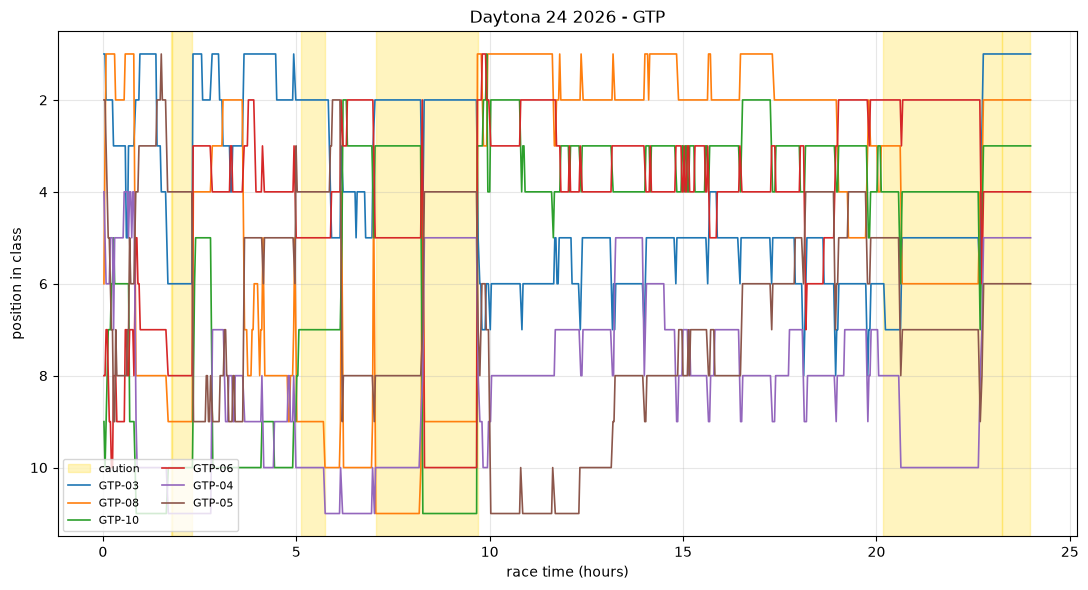

In [10]:
show(viz.plot_race(result, class_name=headline, top_n=6), "race_positions")

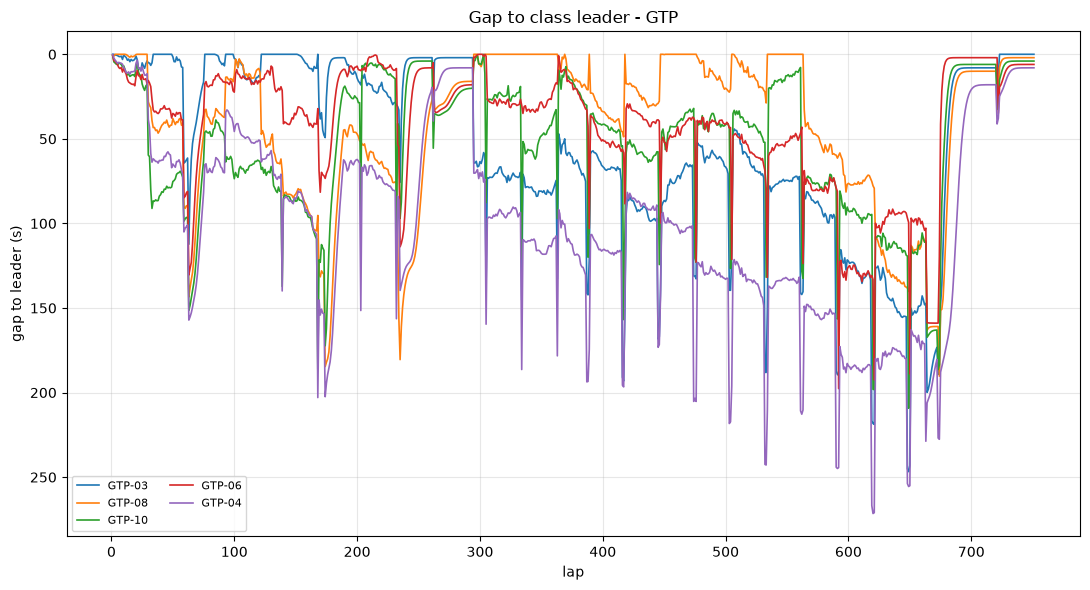

In [11]:
show(viz.plot_gaps(result, class_name=headline, top_n=5), "gaps_to_leader")

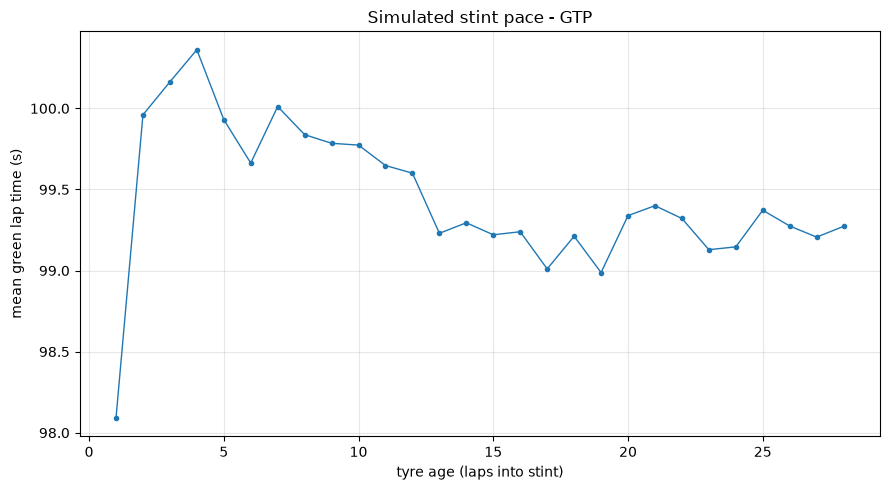

In [12]:
# The same view as notebook 00's stint-pace plot, but produced by the
# simulator - so the two can be compared directly.
show(viz.plot_stint_pace(result, class_name=headline), "stint_pace")

## Part 4 - twist the levers

This is the point of the whole project. `scale_dials` returns a *copy* of
the dials with one of them multiplied, so a lever never edits the engine
and never edits the original calibration - it just hands the engine a
different race.

Below, the caution rate is swept from a quiet race to a chaotic one, with
everything else held fixed. Watch what it does to the number of stops and
to time lost in the pits: in a caution-heavy race, stopping is cheaper, so
the whole rhythm of the race changes.

In [13]:
sweep_rows = []
for mult in [0.0, 0.5, 1.0, 2.0, 3.0, 4.0]:
    cfg = scale_dials(configs[series], caution_rate=mult)
    r = run_race(cfg, seed=SEED)
    c = r.classification()
    c = c[c["class"] == headline]
    sweep_rows.append({
        "caution_multiplier": mult,
        "caution_share": r.cautions.total_caution_s() / cfg.duration_s,
        "mean_laps": c["laps"].mean(),
        "mean_stops": c["stops"].mean(),
        "mean_pit_time_s": c["pit_time_s"].mean(),
    })

sweep = pd.DataFrame(sweep_rows)
sweep

,caution_multiplier,caution_share,mean_laps,mean_stops,mean_pit_time_s
0,0.0,0.000000,842.090909,29.636364,2574.523484
1,0.5,0.159428,796.727273,28.090909,2301.574966
2,1.0,0.318187,751.000000,24.181818,1961.054493
3,2.0,0.674498,646.454545,19.000000,1197.343548
4,3.0,0.942036,565.909091,14.272727,707.709511
5,4.0,0.942036,565.909091,14.272727,707.709511


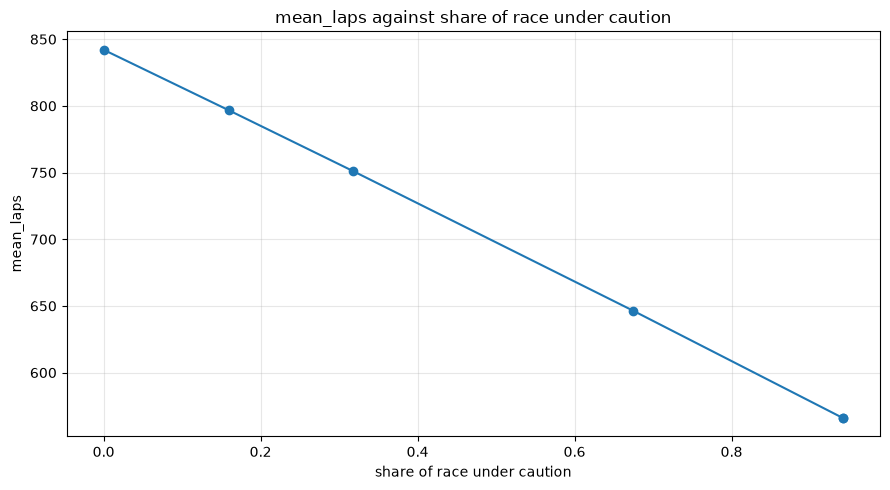

In [14]:
show(viz.plot_lever_sweep(sweep, "caution_share", "mean_laps",
                          label="share of race under caution"), "caution_sweep")

Now the other levers, one at a time, each against the same race. The
comparison is fair because the seed is fixed and the caution timeline does
not depend on what anyone does.

In [15]:
levers = {
    "baseline":                   {},
    "thirstier (+30% fuel burn)": {"fuel_per_lap": 1.3},
    "harsher tyres (x3 deg)":     {"deg_slope_s_per_lap": 3.0},
    "heavier traffic (x3)":       {"traffic_penalty_s": 3.0},
    "slower pit stops (+50%)":    {"pit_time_mean_s": 1.5},
}

rows = []
for name, twist in levers.items():
    cfg = scale_dials(configs[series], **twist) if twist else configs[series]
    c = run_race(cfg, seed=SEED).classification()
    c = c[c["class"] == headline]
    rows.append({"lever": name,
                 "mean_laps": round(c["laps"].mean(), 1),
                 "mean_stops": round(c["stops"].mean(), 1),
                 "pit_time_s": round(c["pit_time_s"].mean()),
                 "traffic_time_s": round(c["traffic_time_s"].mean())})

lever_table = pd.DataFrame(rows)
lever_table["laps_vs_baseline"] = (lever_table["mean_laps"]
                                   - lever_table.loc[0, "mean_laps"]).round(1)
lever_table

,lever,mean_laps,mean_stops,pit_time_s,traffic_time_s,laps_vs_baseline
0,baseline,751.0,24.2,1961,822,0.0
1,thirstier (+30% fuel burn),747.0,30.4,2405,896,-4.0
2,harsher tyres (x3 deg),751.0,24.3,1968,801,0.0
3,heavier traffic (x3),735.0,24.0,1925,2344,-16.0
4,slower pit stops (+50%),741.0,24.0,2891,926,-10.0


## Part 5 - a first strategy comparison

A taster of 02. Three strategies, each given the whole headline class, each
run on the identical race. The differences are strategy, because the race
was fixed before anyone made a decision.

`OpportunistUnderCaution` should beat `RunToFuelWindow` by taking cheap
stops when a caution is out. Note that *how much* it wins by depends on
`pit_caution_discount`, which is an assumed number - so the ranking is more
trustworthy than the margin, and 02 should sweep it before making any claim
about size.

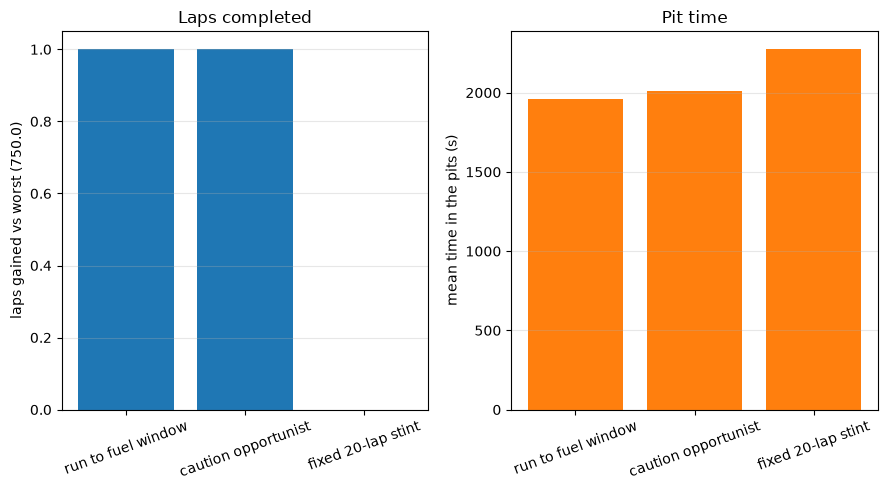

,strategy,mean_laps,mean_stops,pit_time_s,traffic_time_s
0,run to fuel window,751.0,24.181818,1961.054493,822.109091
1,caution opportunist,751.0,28.181818,2012.567107,825.527273
2,fixed 20-lap stint,750.0,38.727273,2272.954486,790.254545


In [16]:
strategy_set = {
    "run to fuel window":  RunToFuelWindow(),
    "caution opportunist": OpportunistUnderCaution(min_fuel_used=0.5),
    "fixed 20-lap stint":  FixedLapStint(stint_laps=20),
}

strategy_results = {
    name: run_race(configs[series],
                   strategies=assign_strategy(configs[series], strat,
                                              class_name=headline),
                   seed=SEED)
    for name, strat in strategy_set.items()
}

fig, comparison = viz.plot_strategy_comparison(strategy_results, headline)
show(fig, "strategy_comparison")
comparison

## Part 6 - does the simulated race resemble the real one?

The engine is only worth anything if a race it produces looks like a race
that happened. Three checks against the source data: laps completed by the
winner, stops made, and share of the race under caution.

These are sanity checks, not a validation gate. A serious gate - the kind
that has to pass before any learning result is admitted - belongs with the
agent work, where being wrong actually costs something.

In [17]:
check_rows = []
for series_code, cfg in configs.items():
    anchor = ANCHORS[series_code]
    hc = anchor["headline_class"]

    sid = RACES[series_code]["session_id"]

    # Stops are counted from the pit records. `MAX(stint_number)` counted
    # driver stints - roughly a third of the stops - which is 00's finding.
    real = con.execute(f"""
        SELECT MAX(laps) AS winner_laps, AVG(stops) AS mean_stops
        FROM (
            SELECT car, MAX(lap) AS laps,
                   SUM(CASE WHEN pit_time IS NOT NULL THEN 1 ELSE 0 END) AS stops
            FROM laps
            WHERE session='race' AND series_code='{series_code}'
              AND class='{hc}' AND session_id = {sid}
            GROUP BY car
        ) t
    """).df().iloc[0]

    # Measured on the same single reference car the calibration used. A
    # caution belongs to the race, not to a car, so pooling the whole field
    # here would compare a field-wide average against a per-car rate and
    # make the two look different when they are not.
    ref_car = con.execute(f"""
        SELECT car FROM laps
        WHERE session='race' AND series_code='{series_code}'
          AND session_id = {sid}
        GROUP BY car ORDER BY COUNT(*) DESC LIMIT 1
    """).fetchone()[0]

    # Caution is a named set. `flags <> 'GF'` swept in the chequered lap.
    real_caution = con.execute(f"""
        SELECT AVG(CASE WHEN flags IN ('FCY', 'SF', 'RF') THEN 1.0 ELSE 0.0 END)
                   AS share
        FROM laps
        WHERE session='race' AND series_code='{series_code}'
          AND session_id = {sid} AND car = '{ref_car}'
          AND flags IN ('GF', 'FCY', 'SF', 'RF')
    """).df().iloc[0]["share"]

    sim = results[series_code]
    sim_c = sim.classification()
    sim_c = sim_c[sim_c["class"] == hc]

    check_rows.append({
        "series": series_code, "class": hc,
        "real_winner_laps": int(real["winner_laps"]),
        "sim_winner_laps": int(sim_c["laps"].max()),
        "real_mean_stops": round(float(real["mean_stops"]), 1),
        "sim_mean_stops": round(float(sim_c["stops"].mean()), 1),
        "real_caution_share": round(float(real_caution), 3),
        "sim_caution_share": round(
            sim.cautions.total_caution_s() / cfg.duration_s, 3),
    })

checks = pd.DataFrame(check_rows)
checks["lap_error_pct"] = ((checks["sim_winner_laps"] - checks["real_winner_laps"])
                           / checks["real_winner_laps"] * 100).round(1)
checks

,series,class,real_winner_laps,sim_winner_laps,real_mean_stops,sim_mean_stops,real_caution_share,sim_caution_share,lap_error_pct
0,imsa,GTP,705,751,29.5,24.2,0.226,0.318,6.5
1,wec,HYPERCAR,381,392,29.6,37.1,0.045,0.060,2.9


## Where this leaves us

**Built:** a calibrated, tested multi-class race engine in
`src/endurance/`, with the five dials as data, every lever exposed through
`scale_dials`, and a strategy interface that the RL agent will implement
unchanged. The test suite in `tests/` guards the properties that matter,
including the one that makes strategy comparison fair.

**Not built yet, on purpose:**

- *Human-style strategies worth beating* - the three above are starters,
  not a serious set. That is 02.
- *The Gymnasium wrapper and the agent* - the engine deliberately has no
  RL dependency, so 03 can wrap it without touching it.
- *Overtaking.* Cars pass by being faster over a lap. A real pass model
  needs parameters no timing sheet contains, and it would be pretending to
  a precision this project does not have.

**The honest caveats.** The dials come from one race per series, so they
describe Daytona and Le Mans rather than IMSA and WEC in general. The
caution model treats cautions as arriving at random, when in truth they
cluster - at night, in traffic, after restarts. And the assumed parameters
listed in Part 1, `pit_caution_discount` above all, do real work in any
result about caution strategy, which is why the strategy comparison in 02
needs to sweep them rather than quote a single number.